In [1]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

**Question 1**
1.   Checking the amount of a bank check that is to be cashed.
2.   Phone number recognition from a contact form.
3. Checking multiple choice homework that is defined by numbers.




In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
print(x_train.shape)

(60000, 28, 28)


In [4]:
# reshape from 28,28 to one 784 dimension
x_train_flat = np.reshape(x_train, (60000, 784), copy=True)
x_test_flat = np.reshape(x_test, (10000, 784), copy=True)

print(x_train_flat.shape)

(60000, 784)


In [5]:
# normalise to values between 0-1 instead of 0-255
x_train_flat = x_train_flat / 255
x_test_flat = x_test_flat / 255

In [6]:
# recategorise values to numerical values 0-9
print(y_train[0:3])
print(np.unique(y_train))

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(y_train[0:3])
print(np.unique(y_train))


[5 0 4]
[0 1 2 3 4 5 6 7 8 9]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
[0. 1.]


In [7]:
model = keras.Sequential()
model.add(keras.layers.Dense(256, input_shape=(784,)))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss='categorical_crossentropy',
optimizer=keras.optimizers.RMSprop(), metrics=['accuracy'])

history = model.fit(x_train_flat, y_train, batch_size=128, epochs=12, verbose=1, validation_split=0.2)

Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8830 - loss: 0.4008 - val_accuracy: 0.9169 - val_loss: 0.3006
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - accuracy: 0.9122 - loss: 0.3118 - val_accuracy: 0.9244 - val_loss: 0.2774
Epoch 3/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - accuracy: 0.9167 - loss: 0.2960 - val_accuracy: 0.9189 - val_loss: 0.2885
Epoch 4/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - accuracy: 0.9194 - loss: 0.2894 - val_accuracy: 0.9168 - val_loss: 0.2936
Epoch 5/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.9219 - loss: 0.2821 - val_accuracy: 0.9247 - val_loss: 0.2800
Epoch 6/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.9214 - loss: 0.2785 - val_accuracy: 0.9186 - val_loss: 0.2974
Epoch 7/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - accuracy: 0.9235 - loss: 0.2757 - val_accuracy: 0.9196 - val_loss: 0.2920
Epoch 8/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - accuracy: 0.9235 - loss: 0.2726 - va

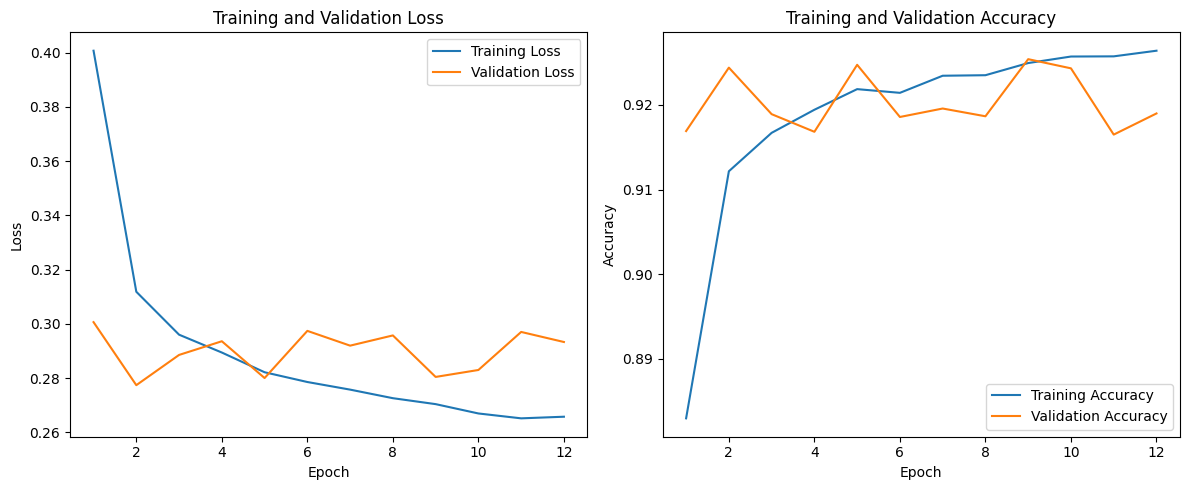

In [9]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

---

**Question 2**


1.   The training loss starts as a higher number compared to the validation loss, similarly the training accuracy also starts lower than the validation accuracy. This is because the training loss is evaluated during the forward pass of the network and the validation loss is evaluated afterwards. Therefore the validation loss is one step behind the training loss calculation, leading to lower validation losses.
2.   The training loss reaches lower values than the validation loss eventually. If this difference would be severe, it could indicate overfitting to the training set.
3. While the training loss decreases with more epochs, the validation loss does not decrease as nearly as significantly. This is another sign of overfitting.
4. The volatility of the validation set is higher than that of the training set. This is likely because (1) the validation set is 4 times smaller than the training set and (2) because the model's update is based on the training set, not on the validation set.
5. The high final validation accuracy (>92%) shows the model generalises well to our validation set beyond our training set. We therefore estimate that our model will also generalise well to an unseen test set.
---


In [10]:
loss, accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.2974
Test accuracy: 0.9169


---

**Question 3**

For all scenarios, we generally think that this accuracy is too low since a human will have a higher accuracy in this task. However, if you are in a situation where there is a strict time constraint for your digitalisation and this level of error is allowed then it is okay. For our mentioned purposes from Q1:


1.   **Bank Check amount**: To avoid fraud we would recommend to use a human for this task.
2.   **Phone number recognition**: Depending on the importance of getting the right number and the number of forms that need to be checked. This could be okay if the cost of errors outweighs the cost of manual checking.
3. **Homework checking**: Again, this depends on the importance of the homework. For ungraded work this is fine, for graded work we recommend a teacher checking the grades and for exams we do not recommend using this model.

EDIT: Important for phone numbers with 10 numbers and long quizes with many answers, the chance of errors is multiplied each use. I.e. for a phone number there is a 43% chance of getting the entire number correct. We therefore do not recommend using it for this purpose. The same holds for a lot of bank checks and homework.



---

---

**Question 4**

The internal operations by the nodes in the network are also linear. By using linear activation functions, we can only get outputs that are linear with respect to the input. A non-linear activation function allows the model to learn non-linear patterns in the data.

Therefore the model itself is also linear.

---


In [11]:
model2 = keras.Sequential()
model2.add(keras.layers.Dense(256, input_shape=(784,), activation="relu"))
model2.add(keras.layers.Dense(10, activation='softmax'))
model2.summary()

model2.compile(loss='categorical_crossentropy',
optimizer=keras.optimizers.RMSprop(), metrics=['accuracy'])

history = model2.fit(x_train_flat, y_train, batch_size=128, epochs=12, verbose=1, validation_split=0.2)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9098 - loss: 0.3226 - val_accuracy: 0.9492 - val_loss: 0.1743
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9570 - loss: 0.1462 - val_accuracy: 0.9647 - val_loss: 0.1238
Epoch 3/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.9712 - loss: 0.0998 - val_accuracy: 0.9694 - val_loss: 0.1040
Epoch 4/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.9776 - loss: 0.0753 - val_accuracy: 0.9726 - val_loss: 0.0940
Epoch 5/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.9829 - loss: 0.0589 - val_accuracy: 0.9738 - val_loss: 0.0868
Epoch 6/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - accuracy: 0.9864 - loss: 0.0464 - val_accuracy: 0.9762 - val_loss: 0.0810
Epoch 7/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.9890 - loss: 0.0376 - val_accuracy: 0.9751 - val_loss: 0.0822
Epoch 8/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - accuracy: 0.9915 - loss: 0.0300 - val_

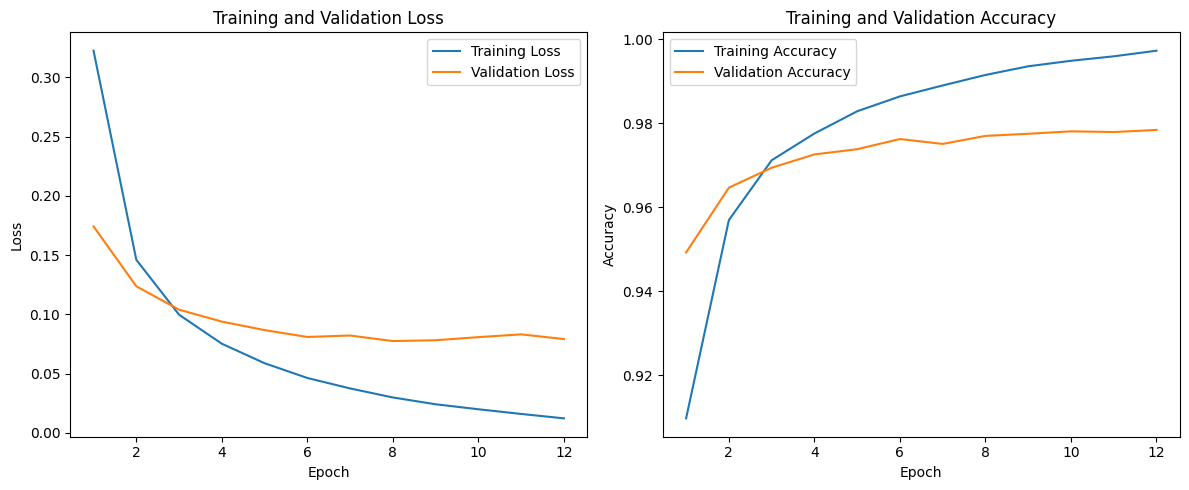

In [12]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
loss, accuracy = model2.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.0704
Test accuracy: 0.9778


---

**Question 5**

Comparing this non-linear model to the previous linear model:

1. The training accuracy of the new model (98%) is much higher compared to the linear model(92%). A similar trend is observed for the valdiation accuracy, thus the non-linear model is expected to have greater generalisation beyond the training data set.
2. The validation loss for the non-linear model is much more stable and it seems to actually converge instead bouncing up and down.
3. If an early stopping algorithm was to be used based on the validation loss, training could be stopped after just a few (~4) epochs because the validation loss stops decreasing. Continuing training can lead to overfitting.
4. There is a larger difference between the training and validation loss at the end of training. Which is also why an early stopping could be beneficial.

EDIT:

5. We observe that the space between the training and validation losses grows as training progresses, indicating overfitting on the training data.
6. The curves for this non-linear model are exponential instead of the more randomly volatile curves observed for the linear model.
---


In [7]:
# Reshape the training and test data to right shapes and normalise
x_train_conv = np.reshape(x_train, (60000, 28, 28, 1), copy=True)
x_test_conv = np.reshape(x_test, (10000, 28, 28, 1), copy=True)

x_train_conv = x_train_conv / 255
x_test_conv = x_test_conv / 255

In [15]:
model3 = keras.Sequential()
model3.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3),
activation="relu", input_shape=(28, 28, 1)))
model3.add(keras.layers.Conv2D(filters=64, kernel_size=(3, 3),
activation="relu"))
model3.add(keras.layers.MaxPool2D(pool_size=(2, 2)))
model3.add(keras.layers.Flatten())
model3.add(keras.layers.Dense(128, activation="relu"))
model3.add(keras.layers.Dense(10, activation="softmax"))

model3.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adadelta(learning_rate=float(1)), metrics=['accuracy'])

history = model3.fit(x_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9337 - loss: 1.0640 - val_accuracy: 0.9753 - val_loss: 0.0790
Epoch 2/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9849 - loss: 0.0528 - val_accuracy: 0.9853 - val_loss: 0.0506
Epoch 3/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9916 - loss: 0.0271 - val_accuracy: 0.9869 - val_loss: 0.0505
Epoch 4/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9959 - loss: 0.0133 - val_accuracy: 0.9870 - val_loss: 0.0549
Epoch 5/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9981 - loss: 0.0068 - val_accuracy: 0.9886 - val_loss: 0.0680
Epoch 6/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9986 - loss: 0.0044 - val_accuracy: 0.9877 - val_loss: 0.0703


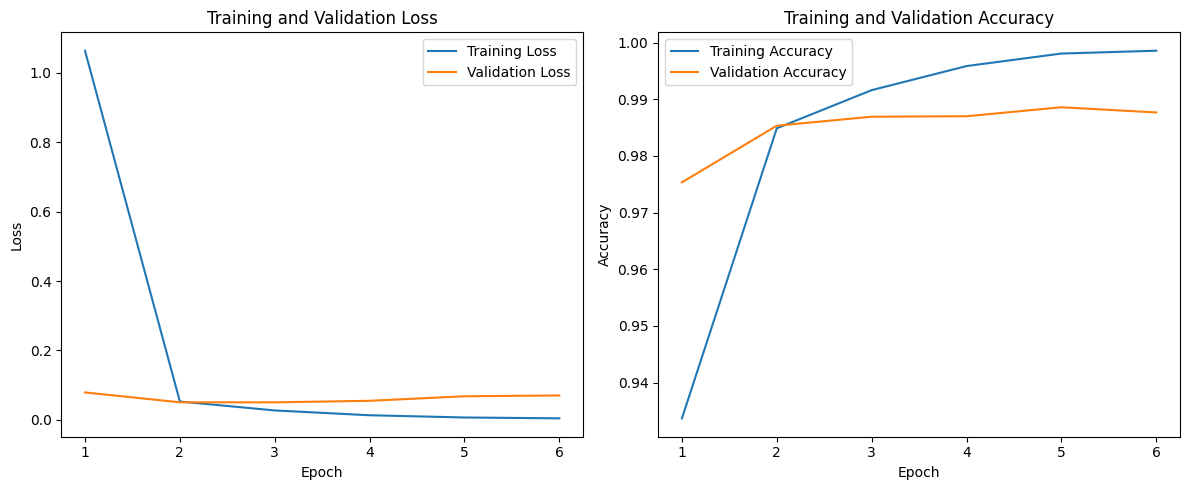

In [16]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
loss, accuracy = model3.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.0615
Test accuracy: 0.9869


---

**Question 6**

Similarely to the previous fully-connected network, this greatly depends on the level of error you can afford. If the task is delicate then you would perhaps prefer a human classfier over an automated one. However, given the test accuracy of 98.6% it is possible that this algorithm outperforms some humans in this task.

This means that this algorithm has a phone number correct 0.986^10 = 86.8% of the time. So for this certain task would it be issuficient

---


In [8]:
model4 = keras.Sequential()
model4.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3),
activation="relu", input_shape=(28, 28, 1)))
model4.add(keras.layers.Conv2D(filters=64, kernel_size=(3, 3),
activation="relu"))
model4.add(keras.layers.MaxPool2D(pool_size=(2, 2)))

# add dropout 1:
model4.add(keras.layers.Dropout(rate=0.25))

model4.add(keras.layers.Flatten())
model4.add(keras.layers.Dense(128, activation="relu"))

# add dropout 2:
model4.add(keras.layers.Dropout(rate=0.50))

model4.add(keras.layers.Dense(10, activation="softmax"))


model4.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adadelta(learning_rate=float(1)),
metrics=['accuracy'])

history = model4.fit(x_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8390 - loss: 0.8769 - val_accuracy: 0.9737 - val_loss: 0.1013
Epoch 2/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9561 - loss: 0.1551 - val_accuracy: 0.9801 - val_loss: 0.0719
Epoch 3/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9701 - loss: 0.1062 - val_accuracy: 0.9827 - val_loss: 0.0608
Epoch 4/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9778 - loss: 0.0753 - val_accuracy: 0.9858 - val_loss: 0.0528
Epoch 5/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9815 - loss: 0.0646 - val_accuracy: 0.9876 - val_loss: 0.0503
Epoch 6/6
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9835 - loss: 0.0571 - val_accuracy: 0.9878 - val_loss: 0.0485


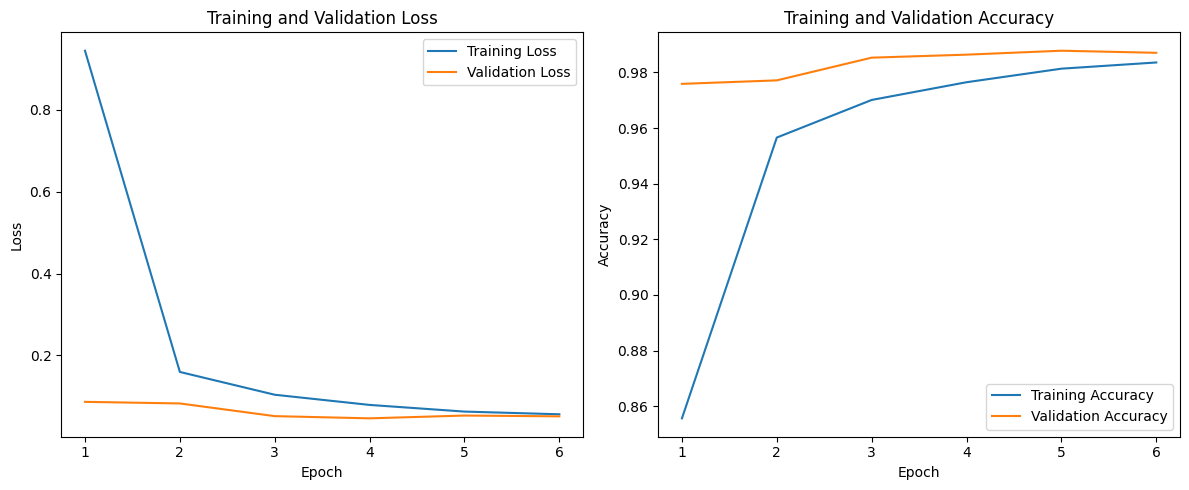

In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model4.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.0509
Test accuracy: 0.9862


---

**Question 7**

* (a) The training time per epoch is quicker because dropout causes each epoch to update fewer parameters.

* (b) The largest immediate benefit of the dropout is the reducing effect of overfitting. The space between the training and validation losses/accuracies is (almost entirely) removed meaning the model performs just as well on the validation data as on the training data after ~6 epochs.
* (c) In conclusion, the less complex model with the suggested dropout implemented generalises better than the non-dropout model due by reducing overfitting. This is also reflected in the test accuracy of the models which increases from 98.6% to 98.7%. A small increase but an increase nonetheless.


---


## Exercise 2

---

**Question 8:**

In [ ]:


# Get an example image from the dataset
example_img = x_train[0]

print(example_img.shape)

(28, 28)


In [27]:
def conv_operation(filters, input_layer):
    """
    Apply valid convolution to a single 3D input layer and a single 3D filter.

    params:
    - filters: 3D filter shaped as (filter_h, filter_w, depth).
    - input_layer: 3D input shaped as (input_h, input_w, depth).

    output:
    - feature_map: 2D array shaped (out_h, out_w)
    """
    filters = np.array(filters)
    input_layer = np.array(input_layer)

    if len(input_layer.shape) != 3:
        raise ValueError("input_layer must be 3D")

    if len(filters.shape) != 3:
        raise ValueError("filters must be 3D")

    filter_h, filter_w, filter_depth = filters.shape
    input_h, input_w, input_depth = input_layer.shape

    if filter_depth != input_depth:
        raise ValueError("Filter depth must match input depth")

    out_h = input_h - filter_h + 1
    out_w = input_w - filter_w + 1

    feature_map = np.zeros((out_h, out_w))
    flattened_filter = filters.reshape(filter_h * filter_w * filter_depth)

    for row in range(out_h):
        for col in range(out_w):
            patch = input_layer[row:row + filter_h, col:col + filter_w, :].reshape(filter_h * filter_w * filter_depth)
            feature_map[row, col] = np.dot(patch, flattened_filter)

    return feature_map

In [29]:
img = x_train[0:4][:, :, None]

# 3x3 edge-detecting filters used for detecting small changes in pixel brightness
horizontal_edges = np.array([
    [[ 1], [ 2], [ 1]],
    [[ 0], [ 0], [ 0]],
    [[-1], [-2], [-1]]
], dtype=float)

vertical_edges = np.array([
    [[ 1], [ 0], [-1]],
    [[ 2], [ 0], [-2]],
    [[ 1], [ 0], [-1]]
], dtype=float)

# Apply convolution separately so each filter output stays separate
result_horizontal = conv_operation(horizontal_edges, img)
result_vertical = conv_operation(vertical_edges, img)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img[:, :, 0], cmap='gray')
axes[0].set_title('Input image')

axes[1].imshow(result_horizontal, cmap='gray')
axes[1].set_title('Horizontal edges')

axes[2].imshow(result_vertical, cmap='gray')
axes[2].set_title('Vertical edges')

plt.show()

ValueError: input_layer must be 3D

---

**Question 9:**

ReLu = max(0, input); setting negatives to 0 and keeping positive inputs.

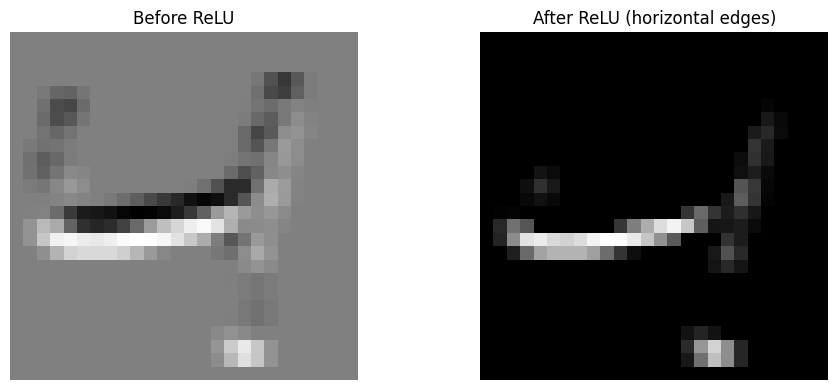

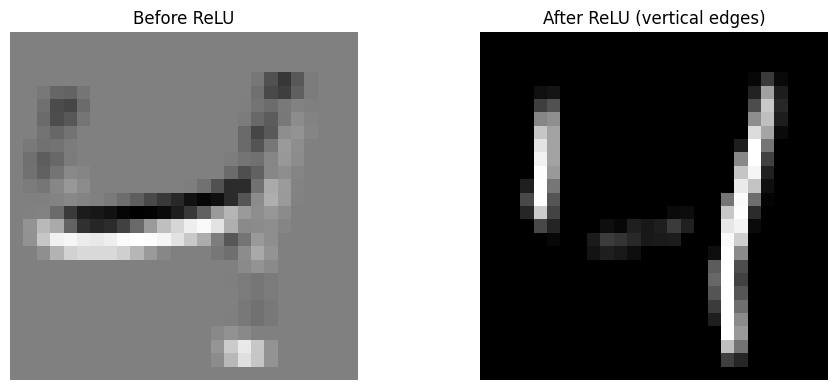

In [ ]:
def relu(feature_map):
    return np.maximum(feature_map, 0)

# Apply ReLU to the horizontal edge map
relu_horizontal = relu(result[0])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(result[0], cmap='gray')
axes[0].set_title('Before ReLU')
axes[1].imshow(relu_horizontal, cmap='gray')
axes[1].set_title('After ReLU (horizontal edges)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


# Apply ReLU to the vertical edge map
relu_vertical = relu(result[1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(result[0], cmap='gray')
axes[0].set_title('Before ReLU')
axes[1].imshow(relu_vertical, cmap='gray')
axes[1].set_title('After ReLU (vertical edges)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


---

**Question 10:**

In [ ]:
def maxpooling(feature_map, pool_size=2, stride=2):
    """
    params:
    - feature_map: 2D array representing the feature map to be pooled.
    - pool_size: size of the pooling window (default is 2).
    - stride: step size for moving the pooling window (default is 2).

    output:
    - pooled_feature_map: 2D array after applying max pooling.
    """
    in_h, in_w = feature_map.shape
    out_h = (in_h - pool_size) // stride + 1
    out_w = (in_w - pool_size) // stride + 1

    pooled_feature_map = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            h_start = i * stride
            h_end = h_start + pool_size
            w_start = j * stride
            w_end = w_start + pool_size

            pooled_feature_map[i, j] = np.max(feature_map[h_start:h_end, w_start:w_end])

    return pooled_feature_map

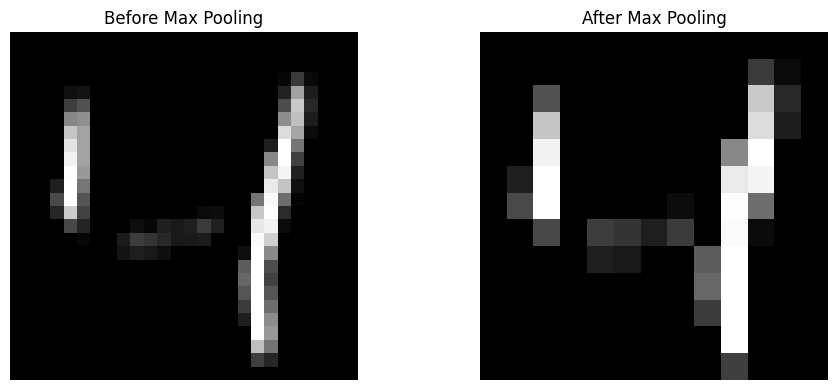

In [ ]:
pooled = maxpooling(relu_vertical, pool_size=2, stride=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(relu_vertical, cmap='gray')
axes[0].set_title('Before Max Pooling')
axes[1].imshow(pooled, cmap='gray')
axes[1].set_title('After Max Pooling')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

---

**Question 11:**

In [ ]:
def normalisation(feature_map):
    mean = np.mean(feature_map)
    std = np.std(feature_map)

    if std == 0:
        return feature_map - mean  # Avoid division by zero

    normalised_feature_map = (feature_map - mean) / std
    return normalised_feature_map

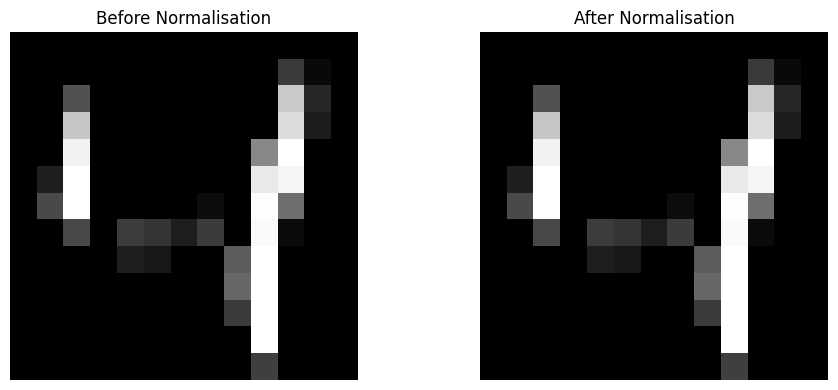

In [ ]:
normalised_layer = normalisation(pooled)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(pooled, cmap='gray')
axes[0].set_title('Before Normalisation')
axes[1].imshow(normalised_layer, cmap='gray')
axes[1].set_title('After Normalisation')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

---

**Question 12:**

In [ ]:
def fully_connected_layer(layer):

  # Flatten imnput layer
  H, W = layer.shape
  flattened = layer.reshape(H * W, )



  # Initialize weights
  num_inputs = flattened.shape[0]
  num_outputs = 10  # Possible outputs

  weights = np.random.randn(num_inputs, num_outputs) * 0.01

  # Check that weights match the number of input nodes
  if weights.shape[0] != flattened.shape[0]:
      raise ValueError("Number of weights does not match number of input nodes")
  print(weights)

  # Output activations
  output = flattened @ weights

  return output



output = fully_connected_layer(normalised_layer)

print(output.shape)

[[ 0.00503454 -0.00950487  0.005886   ... -0.01360724 -0.00616918
   0.00509244]
 [-0.00190055 -0.00559387  0.0130578  ... -0.0015303   0.00376457
   0.00646831]
 [-0.00158936  0.00625683 -0.00161634 ...  0.00403824  0.00082442
  -0.01000699]
 ...
 [-0.01391951 -0.00080314  0.00659694 ...  0.00300304 -0.01282273
   0.02456186]
 [ 0.00748275  0.00844518 -0.00350614 ...  0.00364093  0.0159595
  -0.0109318 ]
 [-0.00794492  0.01499839  0.01751073 ...  0.00828331 -0.01874852
  -0.0046846 ]]
(10,)


---

**Question 13:**

In [ ]:
def softmax_prob(output):

  probabilities = []
  noemer = np.sum(np.exp(output))

  for value in output:
    teller = np.exp(value)

    probabilities.append(teller / noemer)




  return np.array(probabilities)



softmax_prob(output)

array([0.09649398, 0.09899374, 0.10370576, 0.10168094, 0.11298576,
       0.10304619, 0.09114338, 0.10034106, 0.09909166, 0.09251753])

---

## Exercise 3

#### Backpropagation:

In broad terms, backpropagation looks at the prediction of the last forward pass and compares this to a known true solution. Then it goes over the parameters of the model and adjusts them such that it if another similar example is given in the future, the models prediction will be closer to the seen true solution for that input.

More specifically, backpropagation works by computing the gradient of the loss function with respect to each parameter in the network. This is done by applying the chain rule from calculus: the error is propagated backward from the output layer through each intermediate layer, layer by layer, until it reaches the weights and biases. In other words, the network asks: “How much did each weight affect the final error?” Once these gradients are known, an optimizer such as gradient descent updates the weights in the direction that reduces the loss.

##### Text-to-image generation models:
* Transformer language encoders:
* Diffusion models:
* Latent space representations:
* Image autoencoders:


